<a href="https://colab.research.google.com/github/Tdaniels4real/music-popularity-capstone/blob/main/music_popularity_capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Music Popularity Capstone

**Group name:** Group 7  |  **Our genre:** Afrobeat  |  **Date:** September 2026

---
## Part 1 — Load the data
**Weeks 1–2**

##### TASK 1.1: IMPORT LIBRARIES

Let's bring in all the tools we need for the whole project.

* **pandas** = for handling data
* **numpy** = for doing math
* **matplotlib/seaborn** = for making charts

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', None)
print('Ready')

Ready


##### TASK 1.2: YOUR GENRE

We chose **afrobeat** as our genre. Let's set that up. We will also pick a number to keep our random steps the same every time we run the code.

In [ ]:
# Tell the notebook what our genre is
GENRE = 'afrobeat'

# Pick a number to keep our random steps the same
RANDOM_STATE = 42

print(f'Working on: {GENRE}')

Working on: afrobeat



##### TASK 1.3: READ THE DATA FILE

##### Load spotify_tracks.csv directly from our GitHub repo
#####No manual upload needed works in every session



In [ ]:
url = 'https://raw.githubusercontent.com/Tdaniels4real/music-popularity-capstone/refs/heads/main/spotify_tracks.csv'

df = pd.read_csv(url)

print('Rows:', df.shape[0])
print('Columns:', df.shape[1])
df.head()

Rows: 114000
Columns: 21


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


##### TASK 1.4: FIRST LOOK AT THE DATA

Three questions we always ask:
1. What columns do we have?
2. What is missing?
3. What do the numbers look like?

In [ ]:
# What columns do we have?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [ ]:
# What is missing?
df.isnull().sum()

,0
Unnamed: 0,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


In [ ]:
# What do the numbers look like?
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


##### TASK 1.5: CHECK IF OUR GENRE EXISTS

Before we filter out all the other music, we need to double-check that our chosen genre actually exists in the dataset. We are going to look through the list of genres to make sure "afrobeat" is in there and check exactly how it is spelled.

In [ ]:
# Display all unique genre values to verify formatting and spelling
df['track_genre'].unique()

array(['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient',
       'anime', 'black-metal', 'bluegrass', 'blues', 'brazil',
       'breakbeat', 'british', 'cantopop', 'chicago-house', 'children',
       'chill', 'classical', 'club', 'comedy', 'country', 'dance',
       'dancehall', 'death-metal', 'deep-house', 'detroit-techno',
       'disco', 'disney', 'drum-and-bass', 'dub', 'dubstep', 'edm',
       'electro', 'electronic', 'emo', 'folk', 'forro', 'french', 'funk',
       'garage', 'german', 'gospel', 'goth', 'grindcore', 'groove',
       'grunge', 'guitar', 'happy', 'hard-rock', 'hardcore', 'hardstyle',
       'heavy-metal', 'hip-hop', 'honky-tonk', 'house', 'idm', 'indian',
       'indie-pop', 'indie', 'industrial', 'iranian', 'j-dance', 'j-idol',
       'j-pop', 'j-rock', 'jazz', 'k-pop', 'kids', 'latin', 'latino',
       'malay', 'mandopop', 'metal', 'metalcore', 'minimal-techno', 'mpb',
       'new-age', 'opera', 'pagode', 'party', 'piano', 'pop-film', 'pop',
       'pow

In [ ]:
# Check total number of unique genres in the dataset
df['track_genre'].nunique()

114

In [ ]:
print('Is your genre there?', GENRE in df['track_genre'].unique())

Is your genre there? True


##### TASK 1.6: FILTER YOUR GENRE

The original dataset contains tracks from many different genres. Since the genre we chose is Afrobeat, we filter the dataset to keep only the tracks where the genre is equal to "afrobeat".

This ensures that all of our analysis and cleaning from here on out is completely specific to our chosen genre.

In [ ]:
df = df[df['track_genre'] == GENRE].copy()

print(f'{len(df)} tracks in {GENRE}')
df[['track_name', 'artists', 'popularity']].head()

1000 tracks in afrobeat


,track_name,artists,popularity
1000,Jireh (My Provider),Limoblaze;Lecrae;Happi,64
1001,Ainda Há Tempo,Criolo,44
1002,Fellini,Criolo,42
1003,Lion Man,Criolo,46
1004,Espiral de Ilusão,Criolo,44


##### TASK 1.7: THREE OBSERVATIONS

We make three observations from the afrobeat dataset after running summary statistics on popularity and danceability.

We perform descriptive (summary) statistics on popularity and danceability.
Popularity tells us how played the tracks are (0-100).
Danceability tells us how suitable the tracks are for dancing (0-1).

In [ ]:
# Summary statistics for afrobeat popularity and danceability
df[['popularity', 'danceability']].describe()

,popularity,danceability
count,1000.000000,1000.00000
mean,24.399000,0.66958
std,10.512579,0.12384
min,0.000000,0.28500
25%,18.000000,0.58300
50%,21.000000,0.69100
75%,28.000000,0.76225
max,75.000000,0.97400


#### Our Three Observations

**1. The lowest popularity score is 0.**
The minimum popularity score in our afrobeat dataset is 0 out of 100. This means some afrobeat tracks in our data have had little or no plays at all, showing that the genre includes both well-known and completely unknown tracks.

**2. The highest popularity score is 75.**
The maximum popularity score in our afrobeat dataset is 75 out of 100. No afrobeat track in our data reaches the maximum possible score of 100, suggesting these tracks are well-played but not globally chart-topping.

**3. Average danceability is 0.67.**
The mean danceability score for afrobeat tracks is 0.67 on a 0-to-1 scale. This is well above the midpoint of 0.5, confirming that afrobeat is a highly danceable genre.

---
## Part 2 — Clean the data
**Week 3**

Before we can start finding patterns in our music, we need to make sure our dataset is perfectly clean and ready to go.

In Week 3, we will look for and fix any messy parts of our data. This includes throwing away junk columns we don't need, removing duplicate songs, and deleting any rows with missing information.

##### TASK 2.1: DROP THE JUNK COLUMN

When we loaded our music data, an extra column called `Unnamed: 0` sneaked in. This happens because the original file had an empty column name for its row numbers.

Since this column doesn't contain any real music data, it is basically just junk taking up space. So, we are going to drop it from our dataset.

In [ ]:
# Count columns before
initial_count = len(df.columns)

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Count the difference
dropped_count = initial_count - len(df.columns)
print(f"Number of columns dropped: {dropped_count}")
print(list(df.columns))

Number of columns dropped: 1
['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


##### TASK 2.2: REMOVE DUPLICATE TRACKS

Sometimes the exact same song gets recorded in the dataset multiple times. If we leave them in, it will mess up our analysis by counting the same track twice.

We are going to check for any tracks that have the exact same `track_id` and drop the extras.

In [ ]:
# Check how many duplicates we have
print('Duplicate tracks:', df.duplicated(subset='track_id').sum())

# Inspect duplicate records before deletion
# By setting keep=False, it shows us both the original and the copy side-by-side
duplicates = df[df.duplicated(subset='track_id', keep=False)].sort_values('track_name')
display(duplicates[['track_id', 'track_name', 'artists']].head())

# Drop them
df = df.drop_duplicates(subset='track_id')

# See how many tracks are left
print('Tracks left:', len(df))

Duplicate tracks: 1


,track_id,track_name,artists
1874,0CDucx9lKxuCZplLXUz0iX,Song for Rollins,Buena Onda Reggae Club
1925,0CDucx9lKxuCZplLXUz0iX,Song for Rollins,Buena Onda Reggae Club


Tracks left: 999


##### TASK 2.3: DELETE MISSING VALUES

Our models cannot learn from empty data. We need to check if any of our tracks are missing important information like their name, artist, or audio features.

If we find any tracks with missing data, we will drop them from the dataset to keep things clean.

In [ ]:
# Check what is missing before we clean it
print('Missing before:')
print(df.isna().sum()[df.isna().sum() > 0])

# Calculate the percentage of missing data across the entire dataset
total_missing = df.isna().sum().sum()
total_cells = np.prod(df.shape)
percent_missing = (total_missing / total_cells) * 100
print(f"\nWe are missing {round(percent_missing, 2)}% of our total data.")

# Drop any row that has missing data
df = df.dropna()

# Check if it worked
print('\nMissing after:', df.isna().sum().sum())
print('Tracks left:', len(df))

Missing before:
Series([], dtype: int64)

We are missing 0.0% of our total data.

Missing after: 0
Tracks left: 999


##### TASK 2.4: CONVERT THE DURATION

Right now, the length of our songs is stored in **milliseconds**. A number like 300,000 milliseconds is really hard for a human to imagine.

We are going to convert that column into standard minutes so that we can easily see exactly how long our average song is.

In [ ]:
# Create a new column by converting milliseconds into minutes
df['duration_min'] = df['duration_ms'] / 60000

# Print the summary statistics rounded to 2 decimal places
print(df['duration_min'].describe().round(2))

# Drop the original milliseconds column to optimize memory usage
if 'duration_ms' in df.columns:
    df = df.drop(columns=['duration_ms'])
    print("\nDropped the old duration_ms column to save memory.")

count    999.00
mean       4.14
std        1.58
min        0.53
25%        3.24
50%        3.85
75%        4.59
max       13.81
Name: duration_min, dtype: float64

Dropped the old duration_ms column to save memory.


##### TASK 2.5: LOOK AT ODD VALUES
 Look at unusual values (like tracks with 0 popularity or very short length) before deciding whether to remove them.

In [ ]:
# Some tracks have popularity 0 or are very short
# Look before you delete anything

print('Tracks with popularity 0:', (df['popularity'] == 0).sum())
print()
print('Shortest tracks:')
print(df.nsmallest(5, 'duration_min')[['track_name', 'duration_min', 'popularity']])

Tracks with popularity 0: 15

Shortest tracks:
              track_name  duration_min  popularity
1735                Caju      0.530400          18
1574  Canoeiro (vinheta)      0.600100          19
1263         Cool Love 3      0.628367          25
1987          Goldmember      0.963100          18
1807               Omega      1.078217          19


**What this shows:**
* **15 tracks have a popularity of 0.** These are not errors. A popularity of 0 simply means the track has had very few recent plays, which is a genuine result for a lesser-known song.
* **The shortest tracks are under 1.1 minutes** (for example *Caju* at about 0.53 minutes). These look like real interludes and short tracks rather than broken records, and they still have popularity scores between 18 and 25.
* **Decision:** We keep all of these tracks. Deleting them would remove genuine music and make our genre look more popular than it really is.

##### TASK 2.6: CREATE THE HIT LABEL

For Part 5 we need something to classify, so we create a new column called `is_hit`. A track gets a **1** if its popularity is above the median for Afrobeat, and a **0** if not.

Splitting at the median keeps our two groups roughly balanced, which makes a fairer test for our classification models later.

> **Remember this for Part 5:** `is_hit` is built *from* popularity. When we predict it later, we must not use `popularity` as an input, otherwise the model would just be reading the answer.

In [ ]:
# Create a new column 'is_hit': 1 if above median, 0 if below
# This will be our target for Part 5 (classification)

median_pop = df['popularity'].median()
df['is_hit'] = (df['popularity'] > median_pop).astype(int)

print(f'Median popularity in {GENRE}: {median_pop:.0f}')
print(df['is_hit'].value_counts())

Median popularity in afrobeat: 21
is_hit
0    551
1    448
Name: count, dtype: int64


##### CLEANING LOG

| Step | What we found | What we did | Why |
|------|---------------|-------------|-----|
| Junk column | Unnamed: 0 column | Dropped it | No useful information |
| Duplicates | 1 duplicate track_id | Dropped it | Avoid double-counting |
| Missing values | 0 missing values | No action needed | Data was already clean |
| Odd values | 15 tracks with popularity 0 | Kept them | Real tracks, not errors |
| New columns | duration_min added | Converted ms to minutes | Easier to read |
| New columns | is_hit added | Split at median (21) | Target for Part 5 |

---
## Part 3 - Explore The Data
**Week 4**

##### Chart 1 - Who dominates your genre?

A horizontal bar chart of the 10 artists with the most tracks in our Afrobeat dataset. Is the genre spread across many artists, or do a few names take up most of the space?

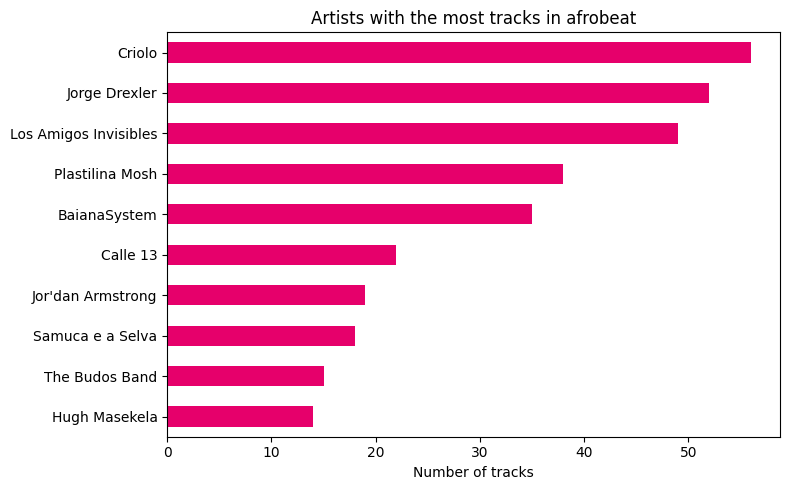

In [ ]:
top = df['artists'].value_counts().head(10)

plt.figure(figsize=(8, 5))
top.sort_values().plot(kind='barh', color='#E6006B')
plt.title(f'Artists with the most tracks in {GENRE}')
plt.xlabel('Number of tracks')
plt.ylabel('')
plt.tight_layout()
plt.show()

**What this shows:**
The afrobeat genre in our dataset is dominated by a small group of artists. Criolo leads with 56 tracks, four times more than the 10th artist (Hugh Masekela, 14). There is a clear gap after the top five artists: each of them has between 35 and 56 tracks, while everyone from 6th place down has 22 or fewer.

##### Chart 2 - How Popular is your genre?

A histogram of popularity scores for every Afrobeat track, with the median marked. Are most of our tracks well-known, or is popularity concentrated in a few songs?

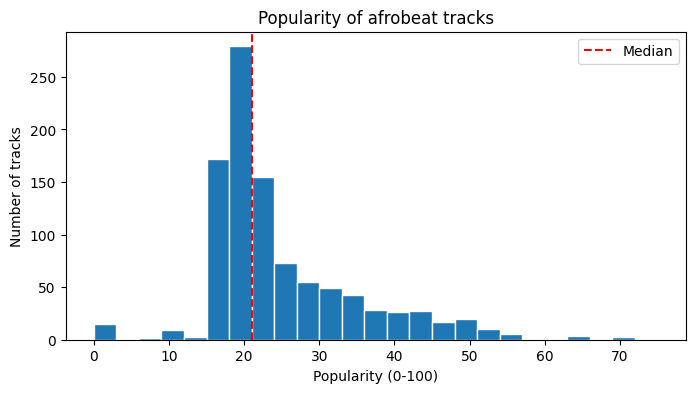

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(df['popularity'], bins=25, edgecolor='white')
plt.axvline(df['popularity'].median(), color='red', linestyle='--', label='Median')
plt.title(f'Popularity of {GENRE} tracks')
plt.xlabel('Popularity (0-100)')
plt.ylabel('Number of tracks')
plt.legend()
plt.show()

**What this shows:**
Most afrobeat tracks in our dataset have low popularity. The distribution peaks around 20 out of 100, with the median at 21, meaning half of all tracks score 21 or below. Very few tracks reach above 50, and there is a small spike at 0 (tracks with very few recent plays). This suggests afrobeat in our dataset is a "long tail" genre: a few standout tracks, with most others remaining relatively unknown.

##### Chart 3 - What moves with what

A correlation heatmap of the audio features. Does danceability rise with energy?

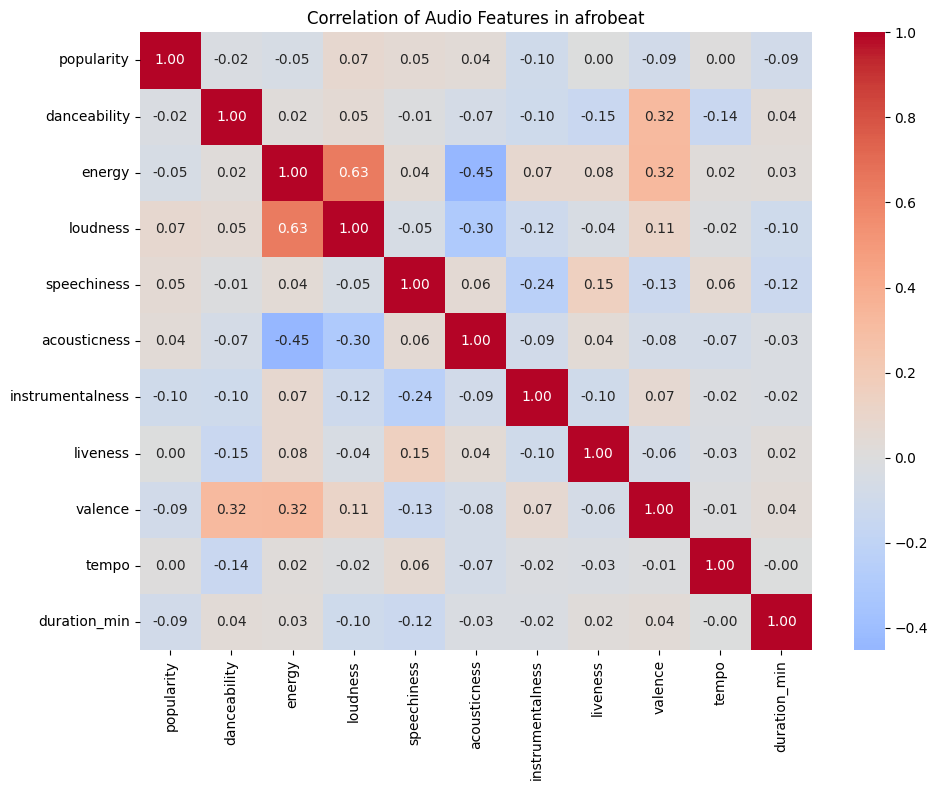

In [ ]:
audio = ['popularity', 'danceability', 'energy', 'loudness', 'speechiness',
         'acousticness', 'instrumentalness', 'liveness', 'valence',
         'tempo', 'duration_min']

plt.figure(figsize=(10, 8))
sns.heatmap(df[audio].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title(f'Correlation of Audio Features in {GENRE}')
plt.tight_layout()
plt.show()

**What this shows:**

Looking at the heatmap, we can make three main observations about Afrobeat tracks:

1. **Energy and Loudness go hand-in-hand:** They have a strong positive relationship (0.63). Louder tracks tend to be higher energy.
2. **Acoustic tracks are lower energy:** There is a moderate negative relationship (-0.45) between acousticness and energy.
3. **Audio features do not guarantee a hit:** Surprisingly, the popularity score has almost zero correlation with any of the audio features (none stronger than about 0.1 in either direction). This means you cannot predict an Afrobeat song's popularity just by looking at how danceable or loud it is.

##### Chart 4 - Does Song Length Matter?

A scatter plot comparing the length of a track in minutes against its popularity score. Do people prefer shorter, punchy Afrobeat songs, or longer jams?

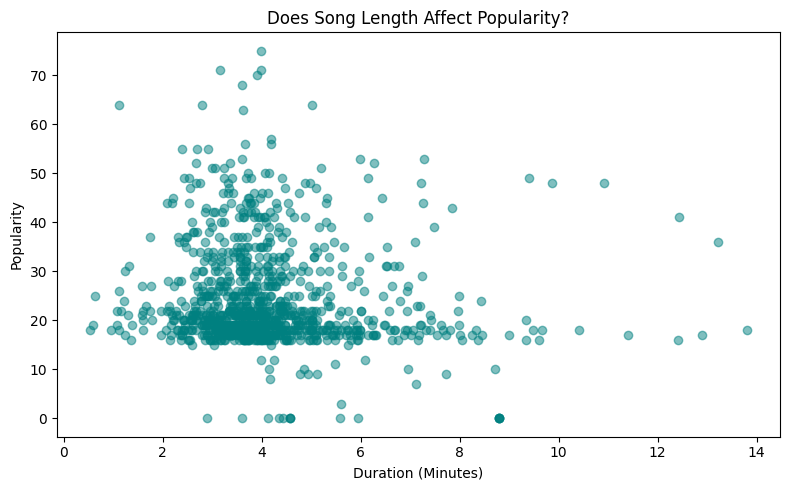

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['duration_min'], df['popularity'], alpha=0.5, color='teal')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Popularity')
plt.title('Does Song Length Affect Popularity?')
plt.tight_layout()
plt.show()

**What this shows:**

Based on the scatter plot, we can see that the most popular Afrobeat songs are mostly clustered between 3 and 4.5 minutes long. The 28 tracks scoring 50 or above have a median length of about 3.6 minutes.

While there are many longer songs in our dataset (197 tracks run over 5 minutes), very few of them reach the highest popularity scores, with a few exceptions (one track over 5 minutes scores 64). This suggests that popular Afrobeat tracks tend to be concise, radio-friendly lengths. However, the pattern is weak: most tracks of every length sit at low popularity, so song length on its own does not make a hit.

---
## Part 4 — Predict Popularity (Regression)
**Week 5**

Now that our Afrobeat dataset is clean and thoroughly explored, we transition to machine learning.

In Week 5, we tackle our first core machine learning challenge: **Can we predict how popular an Afrobeat track will be based on its audio characteristics?**

Because popularity is a continuous numeric score ranging from 0 to 100, this is a **regression** problem.

> **The Golden Rule:** Always split your data first. Learn from the training set, and score honestly on the held-out test set.
>
> **Setting Honest Expectations:** Audio features alone usually predict popularity quite modestly marketing spend, playlist placement, and artist notoriety matter far more in the real music industry. An $R^2$ between 0.05 and 0.20 is completely normal and expected. Explaining *why* it is low demonstrates rigorous, honest data science.


##### TASK 4.1: CHOOSE YOUR INPUTS AND TARGET

Before training our regression models, we must define:
1. **Target ($y$):** The variable we want to predict in our case, `popularity`.
2. **Features ($X$):** The audio attributes our model is allowed to learn from our 10 audio features (`danceability`, `energy`, `loudness`, `speechiness`, `acousticness`, `instrumentalness`, `liveness`, `valence`, `tempo`, and `duration_min`).

> **Guarding Against Data Leakage:** We explicitly leave out `is_hit` from our inputs because it was calculated directly from `popularity`. If we included it, our model would be reading the answer.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Audio features that will serve as our model inputs
features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
            'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_min']

# Define inputs (X) and target (y)
X = df[features]
y = df['popularity']

print('Inputs:', list(X.columns))
print('Total tracks for modeling:', len(X))


Inputs: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_min']
Total tracks for modeling: 999


##### TASK 4.2: SPLIT IT (TRAIN / TEST SPLIT)

To evaluate our regression models honestly, we must never test on the same tracks the model trained on.

We split our data into two distinct subsets:
* **80% Training Set:** Used by our regression algorithms to learn patterns and relationships.
* **20% Testing Set:** Held back and used strictly for evaluation to see how well our models generalize to unseen music.

We pass `random_state=RANDOM_STATE` (42) so that this split is consistent and reproducible across every run.


In [ ]:
# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

print(f'Train: {len(X_train)} tracks ({len(X_train)/len(X)*100:.1f}%)')
print(f'Test : {len(X_test)} tracks ({len(X_test)/len(X)*100:.1f}%)')


Train: 799 tracks (80.0%)
Test : 200 tracks (20.0%)


##### TASK 4.3: MODEL 1 — LINEAR REGRESSION

Now that our data is prepared and split, we train our first predictive model: **Linear Regression**.

In data science, it is best practice to always establish a simple **baseline model** before jumping into complex algorithms. Linear Regression is fast, transparent, and easy to interpret because it assumes a straight-line relationship between each audio feature and popularity.

We fit the model on `X_train` and `y_train`, and then evaluate its predictions on our held-out `X_test` using two standard metrics:
* **Root Mean Squared Error (RMSE):** Tells us how far off our predictions are on average (in points on the 0–100 scale). Lower is better.
* **R-squared ($R^2$):** Measures the proportion of variance in popularity explained by our audio features. 1.0 means perfect prediction, while 0.0 means the model performs no better than guessing the average popularity.


In [ ]:
# Initialize and fit our baseline Linear Regression model
lin = LinearRegression()
lin.fit(X_train, y_train)

# Predict popularity on the unseen test set
pred_lin = lin.predict(X_test)

# Calculate evaluation metrics
rmse_lin = np.sqrt(mean_squared_error(y_test, pred_lin))
r2_lin = r2_score(y_test, pred_lin)

print(f'Linear Regression   RMSE: {rmse_lin:.2f}   R2: {r2_lin:.3f}')


Linear Regression   RMSE: 9.04   R2: 0.019


**What this shows:**
* **Average Error (RMSE = 9.04):** On average, our Linear Regression model predicts an Afrobeat track's popularity to within about **9 points** on the 0–100 scale.
* **Explained Variance ($R^2 = 0.019$):** Our audio features explain only about **1.9%** of the variation in popularity.
* **Key Takeaway:** An $R^2$ near 0.02 is completely expected. Musical features alone (such as danceability and loudness) do not dictate a hit song; cultural buzz, marketing budgets, social media virality, and editorial playlisting account for the rest.


##### TASK 4.4: READ THE COEFFICIENTS

One of the biggest advantages of Linear Regression is that we can open it up and read exactly what it learned.

Each coefficient tells us: *if this feature goes up by one unit (holding everything else constant), the predicted popularity changes by this many points.*

Most of our audio features run from 0 to 1, so "up by one" means moving from the very minimum to the very maximum of that feature. A few features use different units (`loudness` is in decibels, `tempo` in beats per minute, `duration_min` in minutes), so their coefficients describe a much smaller step and should not be compared directly with the 0-to-1 features.

We sort the coefficients from most negative to most positive so the strongest effects sit at either end of the list.

In [ ]:
# Pair each coefficient with its feature name and sort from most negative to most positive
coefs = pd.Series(lin.coef_, index=X.columns).sort_values()
print(coefs.round(3))


energy             -5.420
valence            -3.068
instrumentalness   -1.396
danceability       -1.331
duration_min       -0.392
tempo               0.006
liveness            0.097
loudness            0.536
acousticness        2.042
speechiness         6.128
dtype: float64


**What this shows:**
* **Biggest positive effect: `speechiness` (+6.13).** If an Afrobeat track's speechiness went from 0 to 1, our model predicts its popularity would rise by about **6.1 points**. Tracks with more spoken or rap-style vocals tend to score slightly higher.
* **Biggest negative effect: `energy` (-5.42).** Going from the lowest to the highest energy is linked to a drop of about **5.4 points** in predicted popularity. `valence` (-3.07) also pulls popularity down, so bright, high-intensity tracks are not automatically more popular in our data.
* **Near-zero effects:** `tempo` (0.006 per BPM) and `liveness` (0.097) barely move the prediction at all.
* **Key Takeaway:** Even our strongest feature shifts popularity by only about 6 points across its *entire* range. That fits the low $R^2$ from Task 4.3: no single audio trait strongly drives popularity in Afrobeat.

> **Report sentence:** *"If speechiness goes up by one (from 0 to 1), our model predicts an Afrobeat track's popularity rises by about 6.1 points."*

##### TASK 4.5: MODEL 2 - RANDOM FOREST

Our second model is a **Random Forest Regressor**. Instead of drawing one straight line, it builds 100 decision trees, each trained on a random sample of our training tracks, and averages their predictions.

This makes it far more flexible: it can capture curves, thresholds and combinations of features (for example, *high danceability only helps when energy is moderate*) that a straight line cannot. The trade-off is that we lose the clean, readable coefficient story from Task 4.4.

We train it on exactly the same `X_train` / `y_train` split and score it on the same `X_test`, so the comparison with Linear Regression is fair. We also fix `random_state=RANDOM_STATE` so the forest is reproducible.

In [ ]:
# Initialize and fit a Random Forest with 100 trees
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

# Predict popularity on the same unseen test set
pred_rf = rf.predict(X_test)

# Calculate evaluation metrics
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)

print(f'Random Forest       RMSE: {rmse_rf:.2f}   R2: {r2_rf:.3f}')


Random Forest       RMSE: 9.52   R2: -0.088


**What this shows:**
* **Average Error (RMSE = 9.50):** The Random Forest's predictions are off by about **9.5 points** on average, which is *worse* than Linear Regression's 9.04.
* **Explained Variance ($R^2 = -0.083$):** A negative $R^2$ means the forest does *worse* than simply predicting the average popularity for every track.
* **Key Takeaway:** More complexity did not help. With only 799 training tracks and very weak signal in the audio features, the forest ends up memorising noise in the training set (**overfitting**) instead of learning patterns that carry over to new songs. The simpler model generalises better here.

##### TASK 4.6: COMPARE, AND PLOT PREDICTED AGAINST ACTUAL

Now we put both models side by side. **Lower RMSE is better** and **higher $R^2$ is better**.

We then take whichever model has the lower RMSE and plot its predictions against the true popularity scores for our test tracks. The red dashed diagonal line represents **perfect predictions**: the closer our points hug that line, the better the model.

If the points form a flat, horizontal blob rather than following the diagonal, our model is barely doing better than guessing the average for every song.

               Model   RMSE     R2
0  Linear Regression  9.035  0.019
1      Random Forest  9.518 -0.088


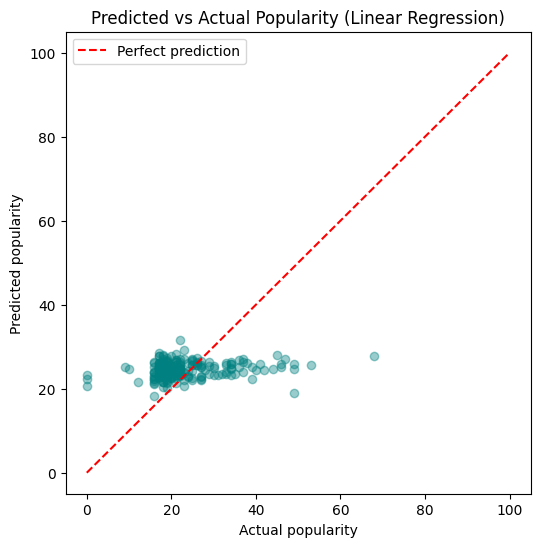

In [ ]:
# Summarise both models in one comparison table
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE': [rmse_lin, rmse_rf],
    'R2': [r2_lin, r2_rf]}).round(3)
print(results)

# Pick the model with the lower error for plotting
best = pred_rf if rmse_rf < rmse_lin else pred_lin
best_name = 'Random Forest' if rmse_rf < rmse_lin else 'Linear Regression'

# Plot predicted vs actual popularity on the test set
plt.figure(figsize=(6, 6))
plt.scatter(y_test, best, alpha=0.4, color='teal')
plt.plot([0, 100], [0, 100], 'r--', label='Perfect prediction')
plt.xlabel('Actual popularity')
plt.ylabel('Predicted popularity')
plt.title(f'Predicted vs Actual Popularity ({best_name})')
plt.legend()
plt.show()


**What this shows:**
* **Winner: Linear Regression.** It has the lower error (RMSE 9.04 vs 9.50) and the higher $R^2$ (0.019 vs -0.083), so it is our best model for Part 4.
* **The plot is a flat blob, not a diagonal line.** The predicted popularity scores sit in a narrow band around the average, while the actual scores spread much wider. Put simply, our model is barely doing better than guessing the average popularity for every Afrobeat track.
* **Key Takeaway:** This is an honest result, not a coding error. The audio features in our dataset simply do not contain the information that decides whether an Afrobeat song becomes popular.

#### Part 4 Write-Up

1. **"Our best model (Linear Regression) predicts popularity to within about 9.04 points on the 0-100 scale."**

2. **"It explains about 1.9% of the variation in popularity ($R^2$ = 0.019)."**

3. **"This means the streaming service should** not rely on audio features alone to forecast Afrobeat track popularity, choose which songs to promote, or decide which artists to sign. Instead, it should combine audio traits with external signals such as the artist's existing follower base, marketing and promotional campaigns, social media virality, and editorial playlist placement."

**Why our $R^2$ is low:**
Audio features describe how a song *sounds* (how danceable, energetic or wordy it is), but they cannot measure what actually drives streams: the artist's fame and fanbase, record label marketing budgets, TikTok and social media trends, radio play, and whether Spotify editors add the track to a major playlist. None of these factors are in our dataset. Our Random Forest's negative $R^2$ supports this: even a flexible model could not find a reliable pattern, because the signal just isn't there in the audio alone.